# Transparency Analysis Notes

This notebook compares PMT charge signals for `Dark`, `Without Window`, and `With Window` data. It applies the same pulse-selection logic to each dataset as defined in `PMT_PROCESSING.ipynb`.

The main final metric is normalized total accepted charge: `sum(accepted charges) / number of waveforms`. This includes both accepted-pulse size and accepted-pulse frequency, so it is more useful for light-through-window comparisons than the mean charge of accepted pulses alone.


# Transparency

In [13]:
# -----------------------------
# Imports
# -----------------------------
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

if not hasattr(np, "trapezoid"):
    np.trapezoid = np.trapz


## Data Locations and Comparison Plan

The external drive folders are grouped by condition and voltage. Edit only `comparison_voltage_values` to choose which voltages to process. The notebook automatically builds the Dark, Without Window, and With Window dataset list and the Dark-reference comparison specifications from that array. I am moving the data to the google drive you just need to download the folders Dark, With Window, and Without Window and the code parses everything else from that

In [14]:
# -----------------------------
# Data locations and settings - NEED TO BE CHANGED IF YOU SAVE THE WAVEFORMS SOMEWHERE ELSE
# -----------------------------
dark_base_folder = "/Volumes/Untitled/Dark"
window_base_folder = "/Volumes/Untitled/With Window"
without_window_base_folder = "/Volumes/Untitled/Without Window"



# There is more data than is currently being ploted. 
# If you want to look at lower voltage data change this array to include the voltages of interest
comparison_voltage_values = np.array([600, 700, 800, 900])

dark_voltage_values = comparison_voltage_values.copy()
test_labels = ["Without Window", "With Window"]
comparison_specs = [
    {"voltage": voltage, "reference_label": "Dark", "test_label": test_label}
    for voltage in comparison_voltage_values
    for test_label in test_labels
]
voltage_values = comparison_voltage_values.copy()

dataset_base_folders = {
    "Dark": dark_base_folder,
    "With Window": window_base_folder,
    "Without Window": without_window_base_folder,
}

#Oscilliscope and Analusis Settings, 
R_TERMINATION = 50.0 
T_PRE_SIGNAL = 20e-9 #the time of arrival is very regular around 40ns so this checks baseline up to about half that 
PULSE_START_TIME = 20e-9
THRESHOLD_SIGMA = 5.0 #I assume 5 sigma variance of the mean noise is sufficient
APPLY_FILTER = True #This only effects the low-pass filter
F_CUTOFF = 1e9 #How strong of a lowpass filter
QC_PERCENTILE = 5
CHARGE_HIST_BINS = 1000

# Folder names on the external drive are numeric voltage labels: 500, 600, etc.
# I changed the naming a few times so this looks for all the different naming conventions to run all accessible data
def find_voltage_folder(base_folder, voltage):
    candidates = [
        os.path.join(base_folder, f"{voltage}"),
        os.path.join(base_folder, f"{voltage}V"),
        os.path.join(base_folder, f"dark_{voltage}"),
        os.path.join(base_folder, f"Dark_{voltage}"),
    ]

    for folder in candidates:
        if os.path.isdir(folder):
            return folder

    # If files are directly inside the base folder, use the base folder.
    if os.path.isdir(base_folder) and glob.glob(os.path.join(base_folder, "C1C*.txt")):
        return base_folder

    return candidates[0]


dataset_specs = []
seen_datasets = set()

# Always process every dark voltage so the final normalized-charge plot shows
# the full dark behavior, not only the voltages used in direct comparisons.
for voltage in dark_voltage_values:
    key = ("Dark", voltage)
    seen_datasets.add(key)
    dataset_specs.append({
        "label": "Dark",
        "voltage": voltage,
        "folder": find_voltage_folder(dark_base_folder, voltage),
    })

# Add the non-dark comparison datasets, while avoiding duplicates.
for comparison in comparison_specs:
    voltage = comparison["voltage"]
    for label in [comparison["reference_label"], comparison["test_label"]]:
        key = (label, voltage)
        if key in seen_datasets:
            continue
        seen_datasets.add(key)
        base_folder = dataset_base_folders[label]
        dataset_specs.append({
            "label": label,
            "voltage": voltage,
            "folder": find_voltage_folder(base_folder, voltage),
        })

for spec in dataset_specs:
    n_files = len(glob.glob(os.path.join(spec["folder"], "C1C*.txt")))
    print(f"{spec['label']:15s} {spec['voltage']} V -> {spec['folder']} ({n_files} files)")


Dark            600 V -> /Volumes/Untitled/Dark/600 (100 files)
Dark            700 V -> /Volumes/Untitled/Dark/700 (100 files)
Dark            800 V -> /Volumes/Untitled/Dark/800 (100 files)
Dark            900 V -> /Volumes/Untitled/Dark/900 (99 files)
Without Window  600 V -> /Volumes/Untitled/Without Window/600 (50 files)
With Window     600 V -> /Volumes/Untitled/With Window/600 (50 files)
Without Window  700 V -> /Volumes/Untitled/Without Window/700 (51 files)
With Window     700 V -> /Volumes/Untitled/With Window/700 (51 files)
Without Window  800 V -> /Volumes/Untitled/Without Window/800 (51 files)
With Window     800 V -> /Volumes/Untitled/With Window/800 (50 files)
Without Window  900 V -> /Volumes/Untitled/Without Window/900 (50 files)
With Window     900 V -> /Volumes/Untitled/With Window/900 (50 files)


## Shared Waveform Processing

These functions are copied from the PMT processing workflow. Each waveform is split from the segmented text file, time-normalized, baseline-subtracted using the pre-pulse region, optionally filtered, and converted into pulse height and charge observables.


In [15]:
# -----------------------------
# Waveform utilities copied from PMT_PROCESSING / Gain_Curve
# -----------------------------
def processing_files(filepath):
    data = np.loadtxt(filepath, delimiter=",", usecols=(0, 1), skiprows=504)
    times = data[:, 0]
    amps = data[:, 1]

    waveforms = []
    current_t = []
    current_a = []

    for i in range(len(times)):
        if i > 0 and times[i] < times[i - 1]:
            waveforms.append((np.array(current_t), np.array(current_a)))
            current_t = []
            current_a = []

        current_t.append(times[i])
        current_a.append(amps[i])

    if current_t:
        waveforms.append((np.array(current_t), np.array(current_a)))

    return waveforms


def normalize_waveform_times(waveforms):
    return [(t - t[0], v) for t, v in waveforms]


def subtract_baseline(waveforms, t_pre_signal=20e-9):
    corrected = []
    baselines = []
    sigmas = []

    for t, v in waveforms:
        mask = t < t_pre_signal

        if np.sum(mask) < 2:
            mask = np.arange(min(10, len(t)))

        baseline = np.mean(v[mask])
        sigma = np.std(v[mask], ddof=1) if np.sum(mask) > 1 else np.std(v[mask])

        corrected.append((t, v - baseline))
        baselines.append(baseline)
        sigmas.append(sigma)

    return corrected, np.array(baselines), np.array(sigmas)


def lowpass_filter_waveform(t, v, f_cut):
    if len(t) < 2:
        return v.copy()

    dt = np.mean(np.diff(t))
    freqs = np.fft.rfftfreq(len(v), d=dt)
    fft_vals = np.fft.rfft(v)

    fft_vals[freqs > f_cut] = 0.0
    return np.fft.irfft(fft_vals, n=len(v))


def filter_waveforms(waveforms, f_cut=1e9):
    return [(t, lowpass_filter_waveform(t, v, f_cut)) for t, v in waveforms]


def extract_observables(waveforms, sigmas, pulse_start_time=20e-9, R=50.0):
    H_list = []
    Q_list = []
    sigma_list = []

    for (t, v), sigma in zip(waveforms, sigmas):
        H = -np.min(v)

        mask = t > pulse_start_time
        if np.sum(mask) < 2:
            Q = np.nan
        else:
            Q = (1.0 / R) * np.trapezoid(-v[mask], t[mask])

        H_list.append(H)
        Q_list.append(Q)
        sigma_list.append(sigma)

    return np.array(H_list), np.array(Q_list), np.array(sigma_list)


def integrate_pulse_region(t, v, R=50.0, pulse_start_time=20e-9):
    if len(t) < 3:
        return np.nan, np.nan, np.nan

    search_mask = t >= pulse_start_time
    if np.sum(search_mask) < 3:
        search_mask = np.ones_like(t, dtype=bool)

    idx_candidates = np.where(search_mask)[0]
    idx_min = idx_candidates[np.argmin(v[search_mask])]

    if v[idx_min] >= 0:
        return 0.0, t[idx_min], t[idx_min]

    i_left = idx_min
    while i_left > 0 and v[i_left] < 0:
        i_left -= 1

    i_right = idx_min
    while i_right < len(v) - 1 and v[i_right] < 0:
        i_right += 1

    if i_right <= i_left:
        return np.nan, np.nan, np.nan

    q = (1.0 / R) * np.trapezoid(-v[i_left:i_right+1], t[i_left:i_right+1])
    return q, t[i_left], t[i_right]


def waveform_duration(waveforms):
    durations = []
    for t, _ in waveforms:
        if len(t) > 1:
            durations.append(t[-1] - t[0])
    return np.array(durations)


## Dataset Metrics

`process_transparency_folder` is the main analysis function. It applies the height and charge cuts, stores all accepted charges, estimates the charge peak, computes average waveforms, and calculates normalized total accepted charge per waveform.

Important distinction: `Charge per waveform [C/wf]` is `total accepted charge / total waveform count`. `Mean accepted pulse charge [C/pulse]` is kept separately as a diagnostic for the average size of pulses that passed the cuts.


In [16]:
# -----------------------------
# Total charge peak and accumulated-charge helpers
# -----------------------------
def estimate_charge_peak(charges, bins=120):
    charges = np.array(charges)
    charges = charges[np.isfinite(charges) & (charges > 0)]

    if len(charges) < 10:
        return np.nan, np.nan, 0, np.array([]), np.array([])

    q_low = np.nanpercentile(charges, 1)
    q_high = np.nanpercentile(charges, 95)
    charges_trim = charges[(charges >= q_low) & (charges <= q_high)]

    if len(charges_trim) < 10 or q_high <= q_low:
        return np.nan, np.nan, 0, np.array([]), np.array([])

    counts, edges = np.histogram(charges_trim, bins=bins)
    idx_peak = np.argmax(counts)
    q_left = edges[max(idx_peak - 1, 0)]
    q_right = edges[min(idx_peak + 2, len(edges) - 1)]
    peak_charges = charges_trim[(charges_trim >= q_left) & (charges_trim <= q_right)]

    q_peak = np.nanmean(peak_charges) if len(peak_charges) else np.nan
    q_peak_err = np.nanstd(peak_charges, ddof=1) / np.sqrt(len(peak_charges)) if len(peak_charges) > 1 else np.nan

    return q_peak, q_peak_err, len(peak_charges), counts, edges


def average_filtered_waveform(waveforms, keep_mask=None):
    if keep_mask is None:
        keep_mask = np.ones(len(waveforms), dtype=bool)
    else:
        keep_mask = np.array(keep_mask, dtype=bool)

    selected = [waveforms[i] for i in range(len(waveforms)) if keep_mask[i]]
    if len(selected) == 0:
        return np.array([]), np.array([]), 0

    t_ref = selected[0][0]
    v_stack = []
    for t, v in selected:
        if len(t) == len(t_ref) and np.allclose(t, t_ref):
            v_stack.append(v)
        else:
            v_stack.append(np.interp(t_ref, t, v))

    return t_ref, np.nanmean(np.vstack(v_stack), axis=0), len(selected)


def process_transparency_folder(data_folder, label, voltage):
    target_files = sorted(glob.glob(os.path.join(data_folder, "C1C*.txt")))

    if len(target_files) == 0:
        return {
            "Label": label,
            "Voltage [V]": voltage,
            "Folder": data_folder,
            "Number of files": 0,
            "Number of waveforms": 0,
            "Accepted pulses N_acc": 0,
            "Total accepted charge [C]": np.nan,
            "Total accepted charge error [C]": np.nan,
            "Charge per waveform [C/wf]": np.nan,
            "Charge per waveform error [C/wf]": np.nan,
            "Mean accepted pulse charge [C/pulse]": np.nan,
            "Mean accepted pulse charge error [C/pulse]": np.nan,
            "Charge peak [C]": np.nan,
            "Charge peak error [C]": np.nan,
            "Charge peak pulses": 0,
            "Accepted charges": np.array([]),
            "All charges": np.array([]),
            "Average time all [s]": np.array([]),
            "Average time accepted [s]": np.array([]),
            "Average time [s]": np.array([]),
            "Average waveform all [V]": np.array([]),
            "Average waveform accepted [V]": np.array([]),
            "Average waveform all N": 0,
            "Average waveform accepted N": 0,
            "Status": "No C1C*.txt files found",
        }

    all_waveforms = []
    for filepath in target_files:
        all_waveforms.extend(processing_files(filepath))

    waveforms_norm = normalize_waveform_times(all_waveforms)
    waveforms_bs, baselines, sigmas = subtract_baseline(waveforms_norm, t_pre_signal=T_PRE_SIGNAL)

    if APPLY_FILTER:
        waveforms_proc = filter_waveforms(waveforms_bs, f_cut=F_CUTOFF)
    else:
        waveforms_proc = waveforms_bs.copy()

    H, Q_full, sigma_evt = extract_observables(
        waveforms_proc,
        sigmas,
        pulse_start_time=PULSE_START_TIME,
        R=R_TERMINATION,
    )

    Q_region = []
    for t, v in waveforms_proc:
        q_i, tl_i, tr_i = integrate_pulse_region(t, v, R=R_TERMINATION, pulse_start_time=PULSE_START_TIME)
        Q_region.append(q_i)

    Q_region = np.array(Q_region)
    sigma_mean = np.nanmean(sigma_evt)
    V_thr = THRESHOLD_SIGMA * sigma_mean
    height_pass = np.isfinite(H) & (H > V_thr)

    accepted_charge_from_height = Q_region[height_pass & np.isfinite(Q_region)]
    Qc = np.nanpercentile(accepted_charge_from_height, QC_PERCENTILE) if len(accepted_charge_from_height) else np.nan
    charge_pass = np.isfinite(Q_region) & (Q_region >= Qc) if np.isfinite(Qc) else np.zeros(len(Q_region), dtype=bool)

    Q_acc = Q_region[charge_pass]
    q_peak, q_peak_err, n_peak, counts, edges = estimate_charge_peak(Q_acc, bins=CHARGE_HIST_BINS)

    avg_t_all, avg_v_all, avg_n_all = average_filtered_waveform(waveforms_proc)
    avg_t_acc, avg_v_acc, avg_n_acc = average_filtered_waveform(waveforms_proc, keep_mask=charge_pass)

    total_charge = np.nansum(Q_acc) if len(Q_acc) else np.nan

    # Normalize by all waveforms. This measures accepted charge per trigger/window,
    # so it includes both pulse size and how often accepted pulses occur.
    mean_accepted_charge = np.nanmean(Q_acc) if len(Q_acc) else np.nan
    mean_accepted_charge_error = (
        np.nanstd(Q_acc, ddof=1) / np.sqrt(len(Q_acc))
        if len(Q_acc) > 1 else np.nan
    )
    total_charge_error = mean_accepted_charge_error * len(Q_acc) if np.isfinite(mean_accepted_charge_error) else np.nan
    charge_per_waveform = total_charge / len(waveforms_proc) if len(waveforms_proc) else np.nan
    charge_per_waveform_error = total_charge_error / len(waveforms_proc) if len(waveforms_proc) and np.isfinite(total_charge_error) else np.nan

    durations = waveform_duration(waveforms_proc)
    T_window = np.nanmean(durations) if len(durations) else np.nan
    T_window_total = len(waveforms_proc) * T_window if np.isfinite(T_window) else np.nan
    charge_rate_window = total_charge / T_window_total if np.isfinite(T_window_total) and T_window_total > 0 else np.nan

    return {
        "Label": label,
        "Voltage [V]": voltage,
        "Folder": data_folder,
        "Number of files": len(target_files),
        "Number of waveforms": len(waveforms_proc),
        "Mean noise sigma [V]": sigma_mean,
        "Voltage threshold V_thr [V]": V_thr,
        "Charge threshold Qc [C]": Qc,
        "Accepted pulses N_acc": int(len(Q_acc)),
        "Total accepted charge [C]": total_charge,
        "Total accepted charge error [C]": total_charge_error,
        "Charge per waveform [C/wf]": charge_per_waveform,
        "Charge per waveform error [C/wf]": charge_per_waveform_error,
        "Mean accepted pulse charge [C/pulse]": mean_accepted_charge,
        "Mean accepted pulse charge error [C/pulse]": mean_accepted_charge_error,
        "Window-normalized charge rate [C/s]": charge_rate_window,
        "Charge peak [C]": q_peak,
        "Charge peak error [C]": q_peak_err,
        "Charge peak pulses": int(n_peak),
        "Accepted charges": Q_acc,
        "All charges": Q_region,
        "Average time all [s]": avg_t_all,
        "Average time accepted [s]": avg_t_acc,
        "Average time [s]": avg_t_all,
        "Average waveform all [V]": avg_v_all,
        "Average waveform accepted [V]": avg_v_acc,
        "Average waveform all N": int(avg_n_all),
        "Average waveform accepted N": int(avg_n_acc),
        "Status": "OK",
    }


## Process All Datasets

This cell runs the analysis for every condition and voltage. The printed file, waveform, accepted-pulse, total-charge, and peak-charge values are the first sanity checks.


In [17]:
# -----------------------------
# Process comparison datasets
# -----------------------------
transparency_results = []

for spec in dataset_specs:
    print(f"Processing {spec['label']} {spec['voltage']} V: {spec['folder']}")
    result = process_transparency_folder(spec["folder"], spec["label"], spec["voltage"])
    transparency_results.append(result)
    print(f"  status    : {result['Status']}")
    print(f"  files     : {result['Number of files']}")
    print(f"  waveforms : {result['Number of waveforms']}")
    print(f"  accepted  : {result['Accepted pulses N_acc']}")
    print(f"  total Q   : {result['Total accepted charge [C]']:.4e} C")
    print(f"  peak Q    : {result['Charge peak [C]']:.4e} C")

print("Done")


Processing Dark 600 V: /Volumes/Untitled/Dark/600
  status    : OK
  files     : 100
  waveforms : 50000
  accepted  : 25305
  total Q   : 1.3216e-09 C
  peak Q    : 3.7785e-14 C
Processing Dark 700 V: /Volumes/Untitled/Dark/700
  status    : OK
  files     : 100
  waveforms : 50000
  accepted  : 36186
  total Q   : 2.0268e-09 C
  peak Q    : 3.8745e-14 C
Processing Dark 800 V: /Volumes/Untitled/Dark/800
  status    : OK
  files     : 100
  waveforms : 50000
  accepted  : 24095
  total Q   : 7.4600e-09 C
  peak Q    : 2.5963e-13 C
Processing Dark 900 V: /Volumes/Untitled/Dark/900
  status    : OK
  files     : 99
  waveforms : 49500
  accepted  : 42881
  total Q   : 1.6807e-08 C
  peak Q    : 1.5889e-13 C
Processing Without Window 600 V: /Volumes/Untitled/Without Window/600
  status    : OK
  files     : 50
  waveforms : 25000
  accepted  : 13785
  total Q   : 7.3246e-10 C
  peak Q    : 3.7537e-14 C
Processing With Window 600 V: /Volumes/Untitled/With Window/600
  status    : OK
  file

## Dark-Reference Comparisons

This table compares each test condition to the dark reference at the same voltage. It reports differences and ratios for total accepted charge, normalized accepted charge per waveform, and charge peak.


In [18]:
# -----------------------------
# Print comparison table
# -----------------------------
def get_result(label, voltage):
    for result in transparency_results:
        if result["Label"] == label and result["Voltage [V]"] == voltage:
            return result
    return None


print("========== TRANSPARENCY CHARGE COMPARISON ==========")
for comparison in comparison_specs:
    voltage = comparison["voltage"]
    ref_label = comparison["reference_label"]
    test_label = comparison["test_label"]
    reference = get_result(ref_label, voltage)
    test = get_result(test_label, voltage)

    if reference is None or test is None:
        continue

    total_excess = test["Total accepted charge [C]"] - reference["Total accepted charge [C]"]
    total_excess_err = np.sqrt(test["Total accepted charge error [C]"]**2 + reference["Total accepted charge error [C]"]**2)
    total_ratio = test["Total accepted charge [C]"] / reference["Total accepted charge [C]"] if reference["Total accepted charge [C]"] > 0 else np.nan
    total_ratio_err = total_ratio * np.sqrt(
        (test["Total accepted charge error [C]"] / test["Total accepted charge [C]"])**2
        + (reference["Total accepted charge error [C]"] / reference["Total accepted charge [C]"])**2
    ) if test["Total accepted charge [C]"] > 0 and reference["Total accepted charge [C]"] > 0 else np.nan

    per_waveform_excess = test["Charge per waveform [C/wf]"] - reference["Charge per waveform [C/wf]"]
    per_waveform_excess_err = np.sqrt(test["Charge per waveform error [C/wf]"]**2 + reference["Charge per waveform error [C/wf]"]**2)
    per_waveform_ratio = test["Charge per waveform [C/wf]"] / reference["Charge per waveform [C/wf]"] if reference["Charge per waveform [C/wf]"] > 0 else np.nan
    per_waveform_ratio_err = per_waveform_ratio * np.sqrt(
        (test["Charge per waveform error [C/wf]"] / test["Charge per waveform [C/wf]"])**2
        + (reference["Charge per waveform error [C/wf]"] / reference["Charge per waveform [C/wf]"])**2
    ) if test["Charge per waveform [C/wf]"] > 0 and reference["Charge per waveform [C/wf]"] > 0 else np.nan

    peak_excess = test["Charge peak [C]"] - reference["Charge peak [C]"]
    peak_excess_err = np.sqrt(test["Charge peak error [C]"]**2 + reference["Charge peak error [C]"]**2)
    peak_ratio = test["Charge peak [C]"] / reference["Charge peak [C]"] if reference["Charge peak [C]"] > 0 else np.nan
    peak_ratio_err = peak_ratio * np.sqrt(
        (test["Charge peak error [C]"] / test["Charge peak [C]"])**2
        + (reference["Charge peak error [C]"] / reference["Charge peak [C]"])**2
    ) if test["Charge peak [C]"] > 0 and reference["Charge peak [C]"] > 0 else np.nan

    print(f"\n{voltage} V: {ref_label} vs {test_label}")
    print(f"  {ref_label} total accepted charge : {reference['Total accepted charge [C]']:.4e} +/- {reference['Total accepted charge error [C]']:.4e} C")
    print(f"  {test_label} total accepted charge : {test['Total accepted charge [C]']:.4e} +/- {test['Total accepted charge error [C]']:.4e} C")
    print(f"  {test_label} - {ref_label} total charge : {total_excess:.4e} +/- {total_excess_err:.4e} C")
    print(f"  {test_label} / {ref_label} total charge : {total_ratio:.4f} +/- {total_ratio_err:.4f}")
    print(f"  {ref_label} charge per waveform : {reference['Charge per waveform [C/wf]']:.4e} +/- {reference['Charge per waveform error [C/wf]']:.4e} C/wf")
    print(f"  {test_label} charge per waveform : {test['Charge per waveform [C/wf]']:.4e} +/- {test['Charge per waveform error [C/wf]']:.4e} C/wf")
    print(f"  {test_label} - {ref_label} charge per waveform : {per_waveform_excess:.4e} +/- {per_waveform_excess_err:.4e} C/wf")
    print(f"  {test_label} / {ref_label} charge per waveform : {per_waveform_ratio:.4f} +/- {per_waveform_ratio_err:.4f}")
    print(f"  {ref_label} charge peak : {reference['Charge peak [C]']:.4e} +/- {reference['Charge peak error [C]']:.4e} C")
    print(f"  {test_label} charge peak : {test['Charge peak [C]']:.4e} +/- {test['Charge peak error [C]']:.4e} C")
    print(f"  {test_label} - {ref_label} charge peak : {peak_excess:.4e} +/- {peak_excess_err:.4e} C")
    print(f"  {test_label} / {ref_label} charge peak : {peak_ratio:.4f} +/- {peak_ratio_err:.4f}")


========== TRANSPARENCY CHARGE COMPARISON ==========

600 V: Dark vs Without Window
  Dark total accepted charge : 1.3216e-09 +/- 5.0625e-12 C
  Without Window total accepted charge : 7.3246e-10 +/- 4.2694e-12 C
  Without Window - Dark total charge : -5.8919e-10 +/- 6.6224e-12 C
  Without Window / Dark total charge : 0.5542 +/- 0.0039
  Dark charge per waveform : 2.6433e-14 +/- 1.0125e-16 C/wf
  Without Window charge per waveform : 2.9298e-14 +/- 1.7078e-16 C/wf
  Without Window - Dark charge per waveform : 2.8654e-15 +/- 1.9853e-16 C/wf
  Without Window / Dark charge per waveform : 1.1084 +/- 0.0077
  Dark charge peak : 3.7785e-14 +/- 2.7477e-18 C
  Without Window charge peak : 3.7537e-14 +/- 3.7453e-18 C
  Without Window - Dark charge peak : -2.4846e-16 +/- 4.6451e-18 C
  Without Window / Dark charge peak : 0.9934 +/- 0.0001

600 V: Dark vs With Window
  Dark total accepted charge : 1.3216e-09 +/- 5.0625e-12 C
  With Window total accepted charge : 9.7591e-10 +/- 5.4331e-12 C
  With W

## Accepted-Charge Distributions

These plots overlay the accepted charge histograms for each test/reference pair. The dashed lines mark the estimated charge peaks used as a diagnostic of pulse size.


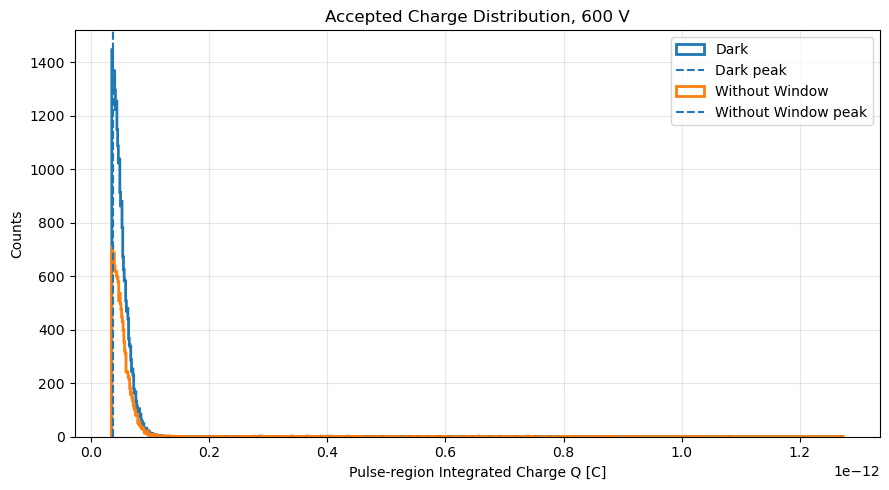

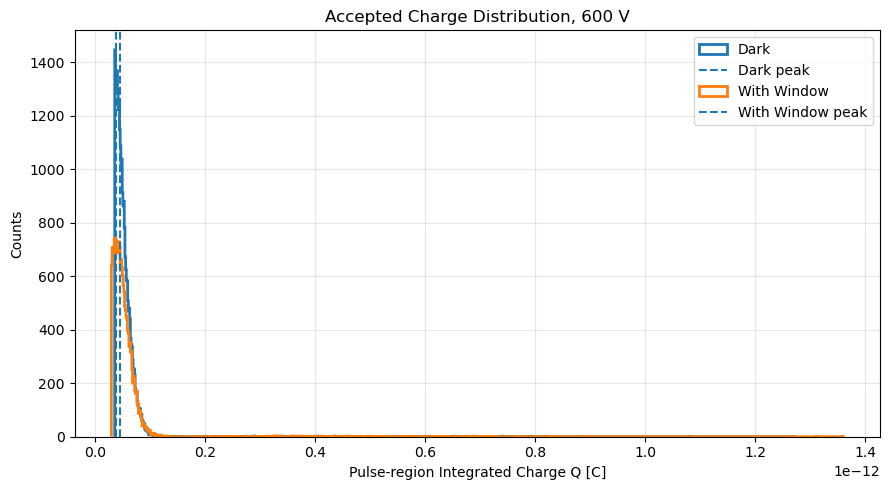

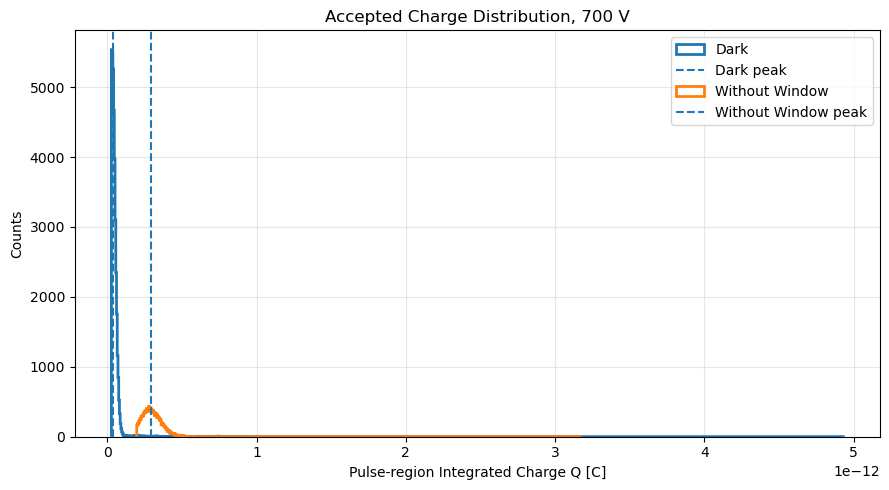

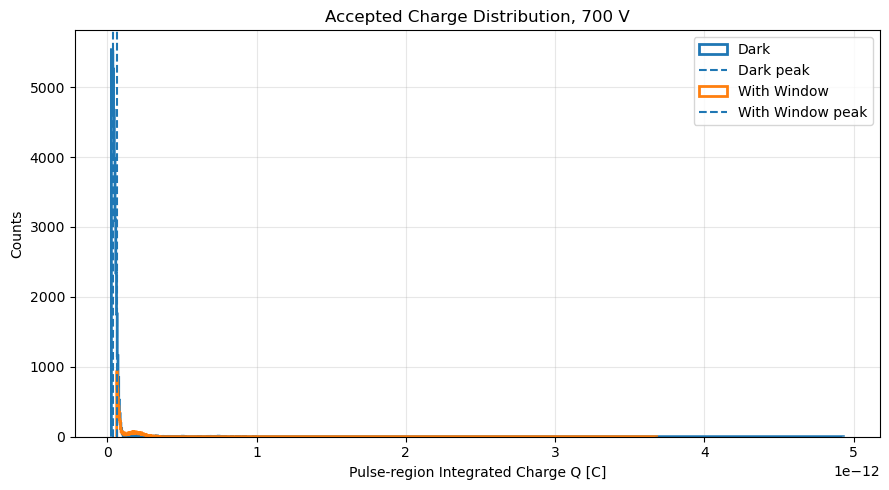

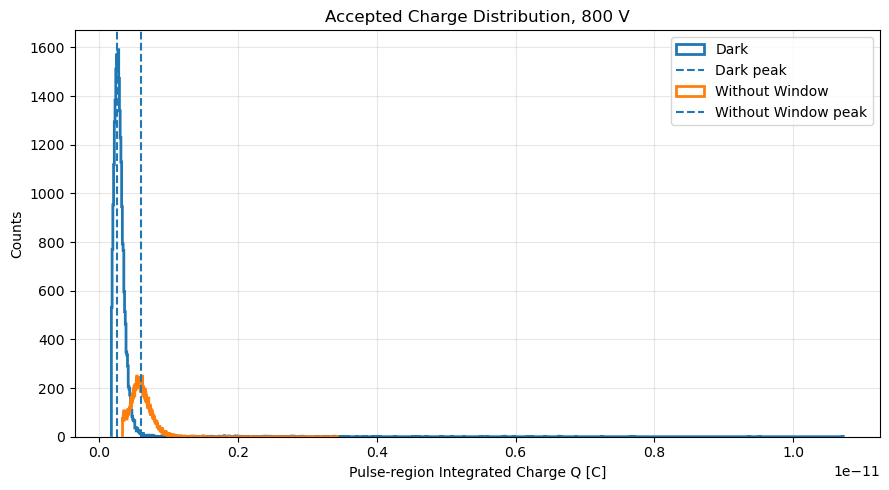

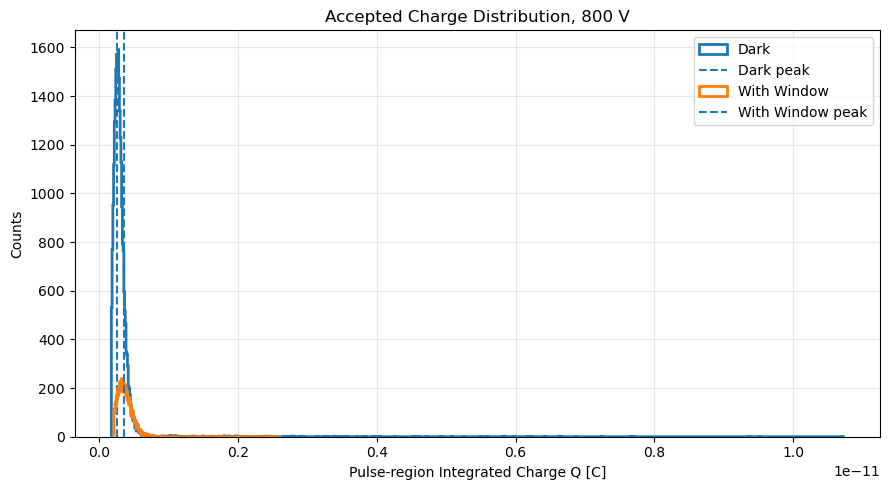

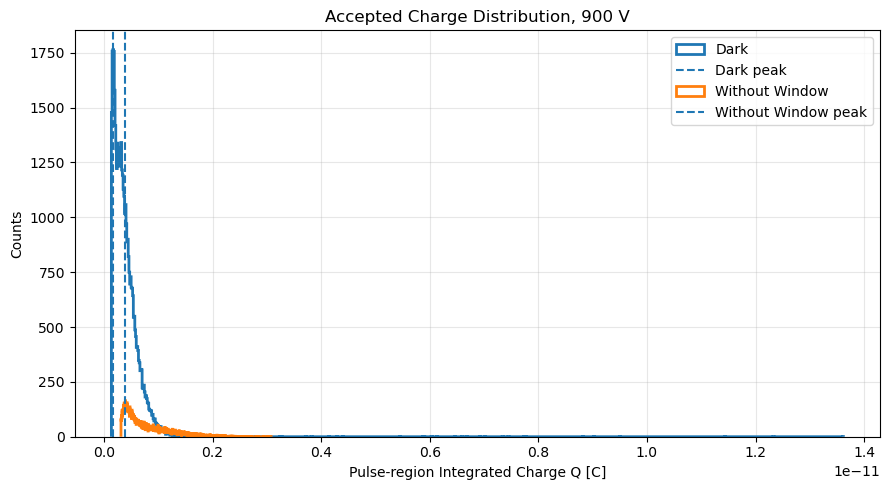

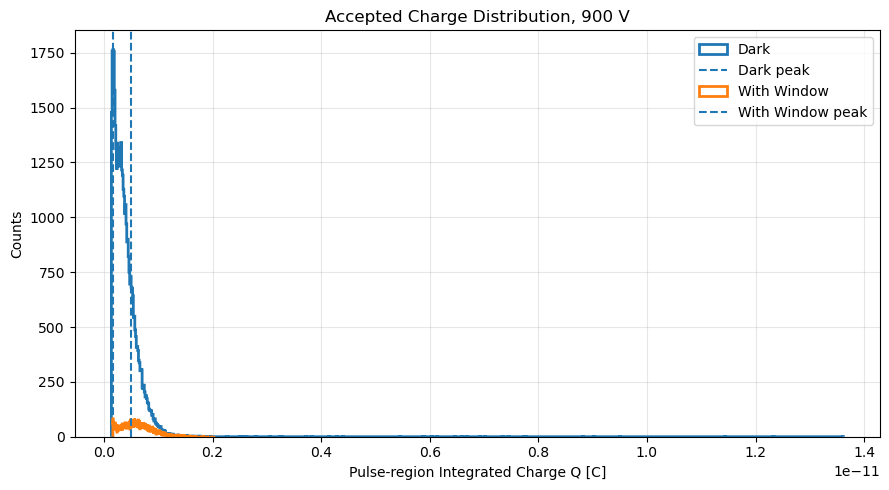

In [19]:
# -----------------------------
# Overlay charge distributions
# -----------------------------
for comparison in comparison_specs:
    voltage = comparison["voltage"]
    ref_label = comparison["reference_label"]
    test_label = comparison["test_label"]
    reference = get_result(ref_label, voltage)
    test = get_result(test_label, voltage)

    if reference is None or test is None:
        continue

    plt.figure(figsize=(9, 5))
    if len(reference["Accepted charges"]):
        plt.hist(reference["Accepted charges"], bins=CHARGE_HIST_BINS, histtype="step", lw=2, label=ref_label)
        plt.axvline(reference["Charge peak [C]"], ls="--", lw=1.5, label=f"{ref_label} peak")
    if len(test["Accepted charges"]):
        plt.hist(test["Accepted charges"], bins=CHARGE_HIST_BINS, histtype="step", lw=2, label=test_label)
        plt.axvline(test["Charge peak [C]"], ls="--", lw=1.5, label=f"{test_label} peak")

    plt.xlabel("Pulse-region Integrated Charge Q [C]")
    plt.ylabel("Counts")
    plt.title(f"Accepted Charge Distribution, {voltage} V")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Average Accepted-Waveform Checks

These plots compare only the average baseline-subtracted filtered waveforms that passed the pulse-selection cuts. This focuses the comparison on accepted pulse shapes and avoids the extra all-waveform panel.


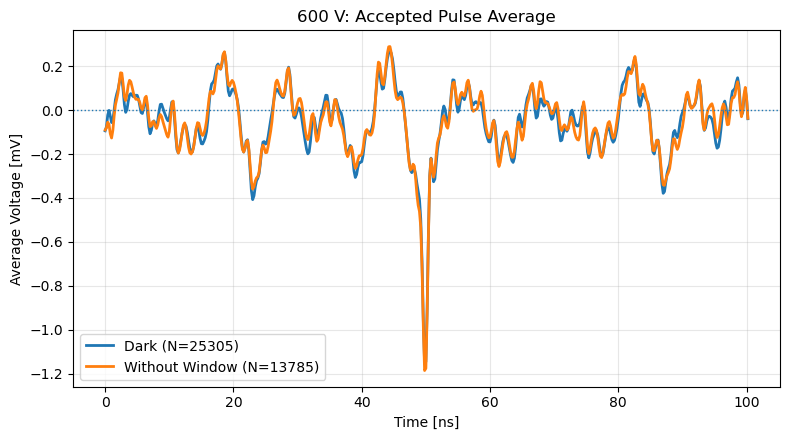

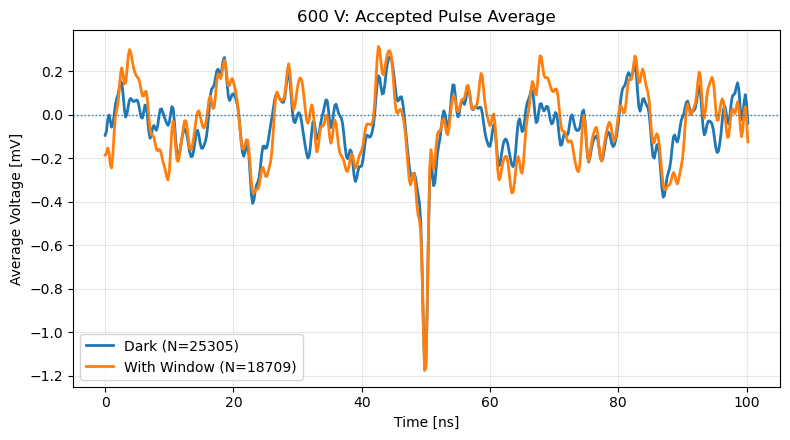

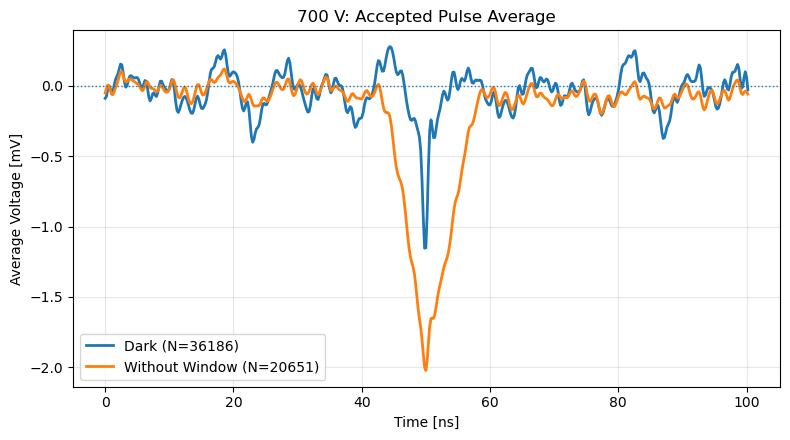

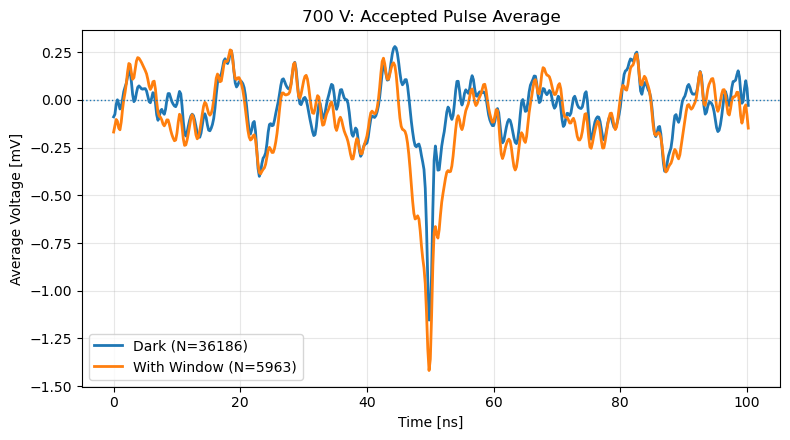

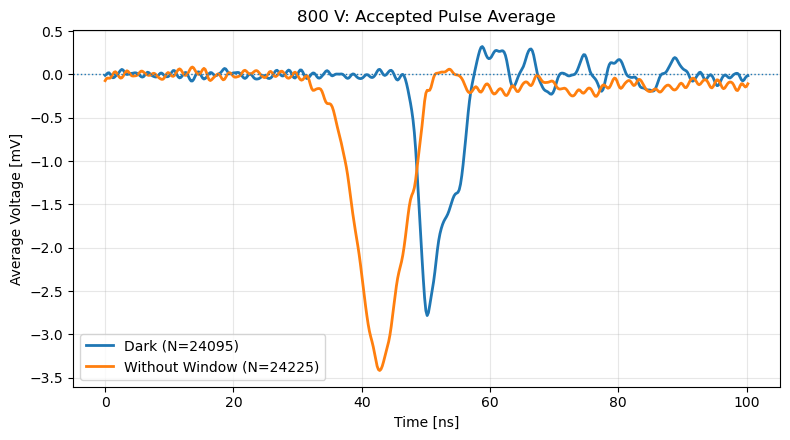

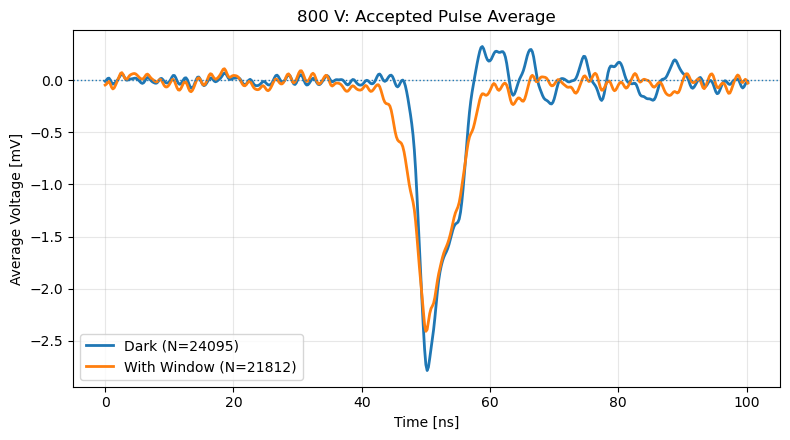

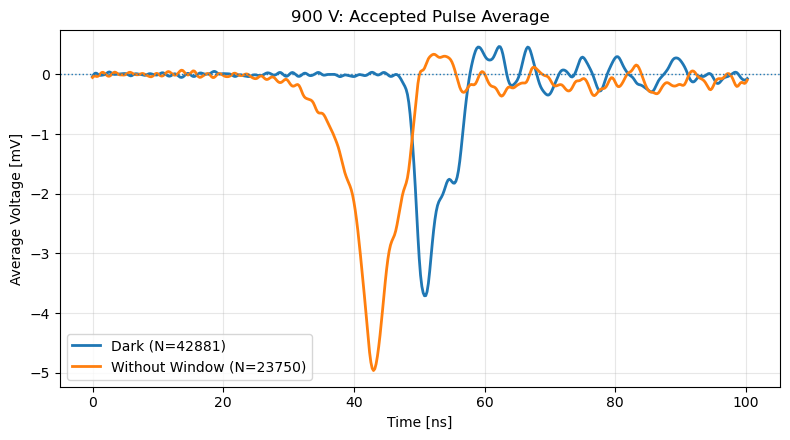

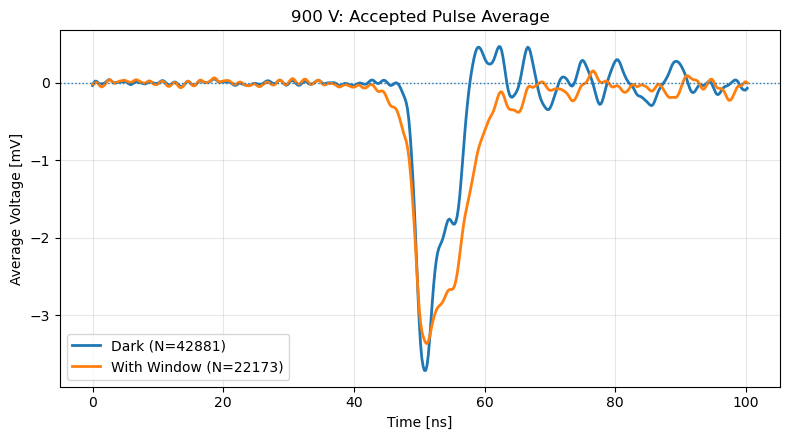

In [20]:
# -----------------------------
# Average accepted waveform comparison
# -----------------------------
# These are baseline-subtracted, filtered averages using only waveforms
# that pass the pulse-selection cuts.
for comparison in comparison_specs:
    voltage = comparison["voltage"]
    ref_label = comparison["reference_label"]
    test_label = comparison["test_label"]
    reference = get_result(ref_label, voltage)
    test = get_result(test_label, voltage)

    if reference is None or test is None:
        continue

    plt.figure(figsize=(8, 4.5))

    for result, color in [(reference, "tab:blue"), (test, "tab:orange")]:
        t_acc_ns = result.get("Average time accepted [s]", result.get("Average time [s]", np.array([]))) * 1e9

        if len(result["Average waveform accepted [V]"]) and len(t_acc_ns) == len(result["Average waveform accepted [V]"]):
            plt.plot(
                t_acc_ns,
                result["Average waveform accepted [V]"] * 1e3,
                lw=2,
                color=color,
                label=f"{result['Label']} (N={result['Average waveform accepted N']})",
            )

    plt.axhline(0, ls=":", lw=1)
    plt.title(f"{voltage} V: Accepted Pulse Average")
    plt.xlabel("Time [ns]")
    plt.ylabel("Average Voltage [mV]")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Test / Dark Ratio Summary

This cell condenses the same-voltage comparisons into ratio plots. Ratios above one mean the test condition has more normalized accepted charge or a larger charge peak than the dark reference.


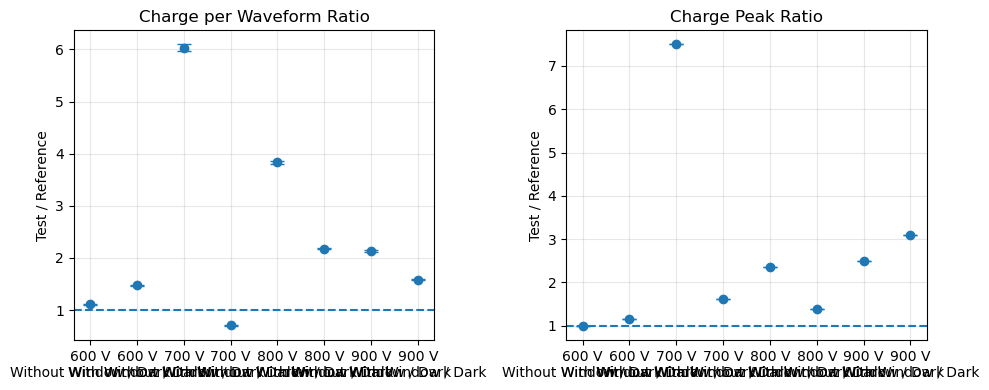

In [21]:
# -----------------------------
# Test / reference ratios with propagated error bars
# -----------------------------
ratio_labels = []
charge_per_waveform_ratios = []
charge_per_waveform_ratio_errors = []
charge_peak_ratios = []
charge_peak_ratio_errors = []

for comparison in comparison_specs:
    voltage = comparison["voltage"]
    ref_label = comparison["reference_label"]
    test_label = comparison["test_label"]
    reference = get_result(ref_label, voltage)
    test = get_result(test_label, voltage)

    if reference is None or test is None:
        continue

    ratio_labels.append(f"{voltage} V\n{test_label} / {ref_label}")

    cpw_ratio = test["Charge per waveform [C/wf]"] / reference["Charge per waveform [C/wf]"]
    cpw_ratio_err = cpw_ratio * np.sqrt(
        (test["Charge per waveform error [C/wf]"] / test["Charge per waveform [C/wf]"])**2
        + (reference["Charge per waveform error [C/wf]"] / reference["Charge per waveform [C/wf]"])**2
    )
    charge_per_waveform_ratios.append(cpw_ratio)
    charge_per_waveform_ratio_errors.append(cpw_ratio_err)

    peak_ratio = test["Charge peak [C]"] / reference["Charge peak [C]"]
    peak_ratio_err = peak_ratio * np.sqrt(
        (test["Charge peak error [C]"] / test["Charge peak [C]"])**2
        + (reference["Charge peak error [C]"] / reference["Charge peak [C]"])**2
    )
    charge_peak_ratios.append(peak_ratio)
    charge_peak_ratio_errors.append(peak_ratio_err)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].errorbar(ratio_labels, charge_per_waveform_ratios, yerr=charge_per_waveform_ratio_errors, fmt="o", capsize=5)
axes[0].axhline(1.0, ls="--", lw=1.5)
axes[0].set_ylabel("Test / Reference")
axes[0].set_title("Charge per Waveform Ratio")
axes[0].grid(True, alpha=0.3)

axes[1].errorbar(ratio_labels, charge_peak_ratios, yerr=charge_peak_ratio_errors, fmt="o", capsize=5)
axes[1].axhline(1.0, ls="--", lw=1.5)
axes[1].set_ylabel("Test / Reference")
axes[1].set_title("Charge Peak Ratio")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Final Normalized-Charge Plot

This is the main absolute comparison plot. Each bar is total accepted charge divided by total waveform count for one voltage and condition.


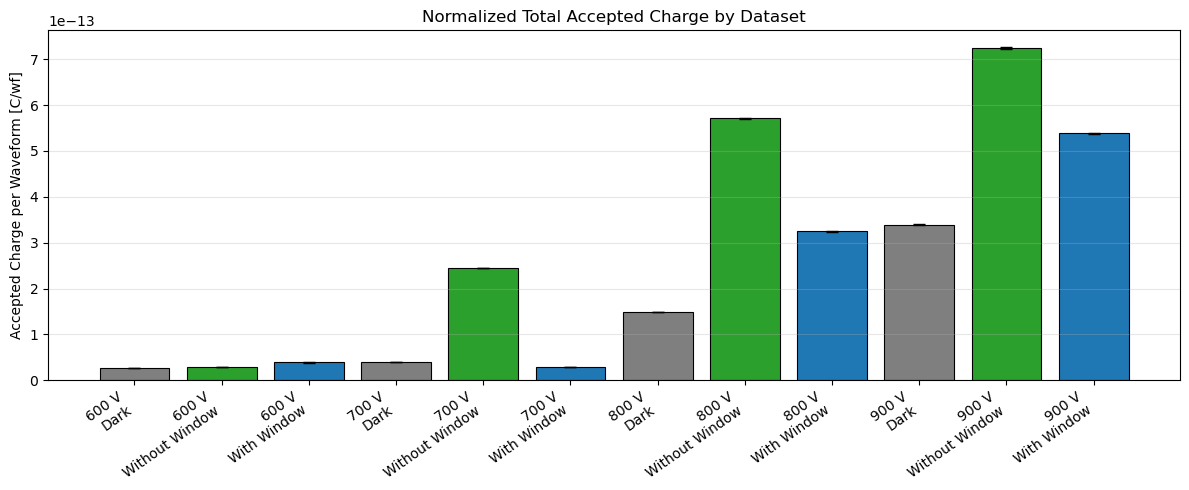

In [22]:
# -----------------------------
# Final normalized-charge plot
# -----------------------------
# This is the main comparison plot. Charge per waveform is the total accepted
# charge divided by the total number of waveforms in each dataset.
plot_order = {"Dark": 0, "Without Window": 1, "With Window": 2}
plot_results = sorted(
    [result for result in transparency_results if result["Status"] == "OK"],
    key=lambda result: (result["Voltage [V]"], plot_order.get(result["Label"], 99)),
)

labels = [f"{result['Voltage [V]']} V\n{result['Label']}" for result in plot_results]
charge_per_waveform = [result["Charge per waveform [C/wf]"] for result in plot_results]
charge_per_waveform_errors = [result["Charge per waveform error [C/wf]"] for result in plot_results]
colors = [
    "tab:gray" if result["Label"] == "Dark"
    else "tab:green" if result["Label"] == "Without Window"
    else "tab:blue"
    for result in plot_results
]

plt.figure(figsize=(12, 5))
plt.bar(
    labels,
    charge_per_waveform,
    yerr=charge_per_waveform_errors,
    capsize=4,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
)
plt.ylabel("Accepted Charge per Waveform [C/wf]")
plt.title("Normalized Total Accepted Charge by Dataset")
plt.xticks(rotation=35, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Voltage-Ratio Plot: 800 V / 700 V

This plot compares how the normalized accepted charge changes from 700 V to 800 V within each condition. It is not a window/dark ratio; it is a voltage-scaling ratio computed separately for Dark, Without Window, and With Window.


Dark: (800 V / 700 V) = 3.6807 +/- 0.0455
Without Window: (800 V / 700 V) = 2.3384 +/- 0.0051
With Window: (800 V / 700 V) = 11.3795 +/- 0.1159


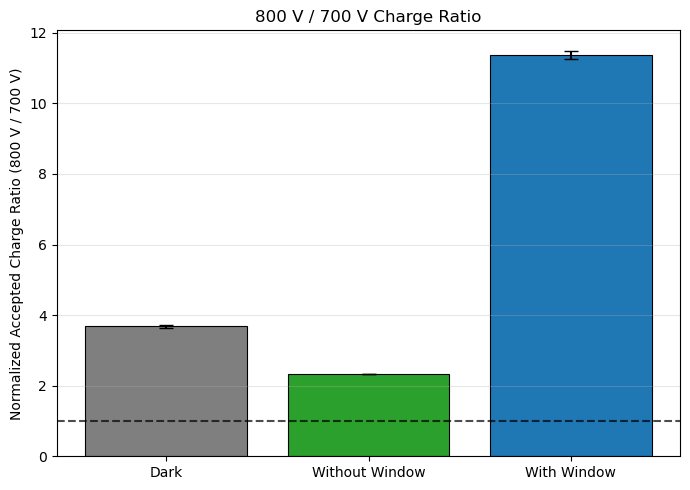

In [23]:
# -----------------------------
# Final ratio plot: 800 V / 700 V normalized accepted charge
# -----------------------------
ratio_dataset_labels = ["Dark", "Without Window", "With Window"]
ratio_low_voltage = 700
ratio_high_voltage = 800

ratio_values = []
ratio_errors = []
ratio_plot_labels = []

for label in ratio_dataset_labels:
    low = get_result(label, ratio_low_voltage)
    high = get_result(label, ratio_high_voltage)

    if low is None or high is None:
        print(f"Missing {label} {ratio_low_voltage} V or {ratio_high_voltage} V result")
        continue

    q_low = low["Charge per waveform [C/wf]"]
    q_high = high["Charge per waveform [C/wf]"]
    err_low = low["Charge per waveform error [C/wf]"]
    err_high = high["Charge per waveform error [C/wf]"]

    ratio = q_high / q_low if q_low > 0 else np.nan
    ratio_err = (
        ratio * np.sqrt((err_high / q_high)**2 + (err_low / q_low)**2)
        if q_high > 0 and q_low > 0 and np.isfinite(err_high) and np.isfinite(err_low)
        else np.nan
    )

    ratio_plot_labels.append(label)
    ratio_values.append(ratio)
    ratio_errors.append(ratio_err)

    print(f"{label}: ({ratio_high_voltage} V / {ratio_low_voltage} V) = {ratio:.4f} +/- {ratio_err:.4f}")

colors = [
    "tab:gray" if label == "Dark"
    else "tab:green" if label == "Without Window"
    else "tab:blue"
    for label in ratio_plot_labels
]

plt.figure(figsize=(7, 5))
plt.bar(
    ratio_plot_labels,
    ratio_values,
    yerr=ratio_errors,
    capsize=5,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
)
plt.axhline(1.0, ls="--", lw=1.5, color="black", alpha=0.7)
plt.ylabel(f"Normalized Accepted Charge Ratio ({ratio_high_voltage} V / {ratio_low_voltage} V)")
plt.title(f"{ratio_high_voltage} V / {ratio_low_voltage} V Charge Ratio")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Voltage-Ratio Plot: 900 V / 800 V

This plot repeats the voltage-scaling comparison for 900 V divided by 800 V.


Dark: (900 V / 800 V) = 2.2757 +/- 0.0150
Without Window: (900 V / 800 V) = 1.2668 +/- 0.0048
With Window: (900 V / 800 V) = 1.6582 +/- 0.0059


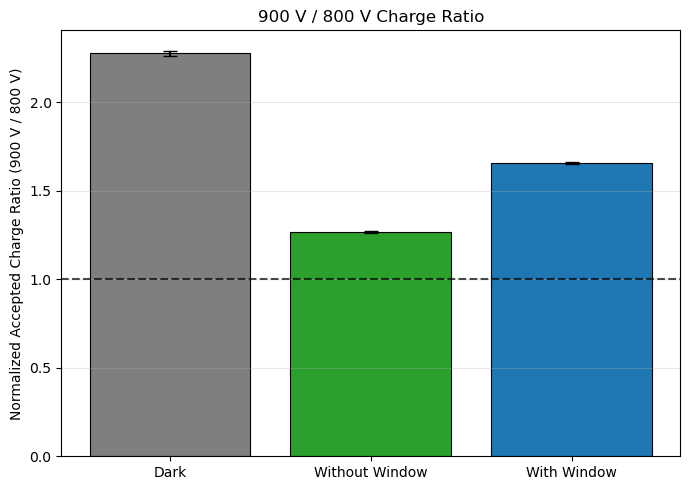

In [24]:
# -----------------------------
# Final ratio plot: 900 V / 800 V normalized accepted charge
# -----------------------------
ratio_dataset_labels = ["Dark", "Without Window", "With Window"]
ratio_low_voltage = 800
ratio_high_voltage = 900

ratio_values = []
ratio_errors = []
ratio_plot_labels = []

for label in ratio_dataset_labels:
    low = get_result(label, ratio_low_voltage)
    high = get_result(label, ratio_high_voltage)

    if low is None or high is None:
        print(f"Missing {label} {ratio_low_voltage} V or {ratio_high_voltage} V result")
        continue

    q_low = low["Charge per waveform [C/wf]"]
    q_high = high["Charge per waveform [C/wf]"]
    err_low = low["Charge per waveform error [C/wf]"]
    err_high = high["Charge per waveform error [C/wf]"]

    ratio = q_high / q_low if q_low > 0 else np.nan
    ratio_err = (
        ratio * np.sqrt((err_high / q_high)**2 + (err_low / q_low)**2)
        if q_high > 0 and q_low > 0 and np.isfinite(err_high) and np.isfinite(err_low)
        else np.nan
    )

    ratio_plot_labels.append(label)
    ratio_values.append(ratio)
    ratio_errors.append(ratio_err)

    print(f"{label}: ({ratio_high_voltage} V / {ratio_low_voltage} V) = {ratio:.4f} +/- {ratio_err:.4f}")

colors = [
    "tab:gray" if label == "Dark"
    else "tab:green" if label == "Without Window"
    else "tab:blue"
    for label in ratio_plot_labels
]

plt.figure(figsize=(7, 5))
plt.bar(
    ratio_plot_labels,
    ratio_values,
    yerr=ratio_errors,
    capsize=5,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
)
plt.axhline(1.0, ls="--", lw=1.5, color="black", alpha=0.7)
plt.ylabel(f"Normalized Accepted Charge Ratio ({ratio_high_voltage} V / {ratio_low_voltage} V)")
plt.title(f"{ratio_high_voltage} V / {ratio_low_voltage} V Charge Ratio")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()